In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style
sns.set_theme(style="whitegrid")

# Load the data
base_linux = pd.read_csv('real_first/base_linux.csv')
base_unikernel = pd.read_csv('real_first/base_unikernel.csv')
optimized_linux = pd.read_csv('real_first/optimized_linux.csv')
optimized_unikernel = pd.read_csv('real_first/optimized_unikernel.csv')

# Add source column to identify each dataset
base_linux['source'] = 'Base Linux'
base_unikernel['source'] = 'Base Unikernel'
optimized_linux['source'] = 'Optimized Linux'
optimized_unikernel['source'] = 'Optimized Unikernel'

# Combine all data
all_data = pd.concat([base_linux, base_unikernel, optimized_linux, optimized_unikernel], ignore_index=True)

print("Unique benchmarks:", all_data['benchmark'].unique())
print("\nData shape:", all_data.shape)
print("\nSamples per benchmark and source:")
print(all_data.groupby(['benchmark', 'source']).size().unstack(fill_value=0))

Unique benchmarks: ['crc32' 'cubic' 'dijkstra' 'fdct' 'fir' 'matmult-float' 'matmult-int'
 'nettle-sha256' 'rijndael']

Data shape: (1350, 18)

Samples per benchmark and source:
source         Base Linux  Base Unikernel  Optimized Linux
benchmark                                                 
crc32                  50              50               50
cubic                  50              50               50
dijkstra               50              50               50
fdct                   50              50               50
fir                    50              50               50
matmult-float          50              50               50
matmult-int            50              50               50
nettle-sha256          50              50               50
rijndael               50              50               50


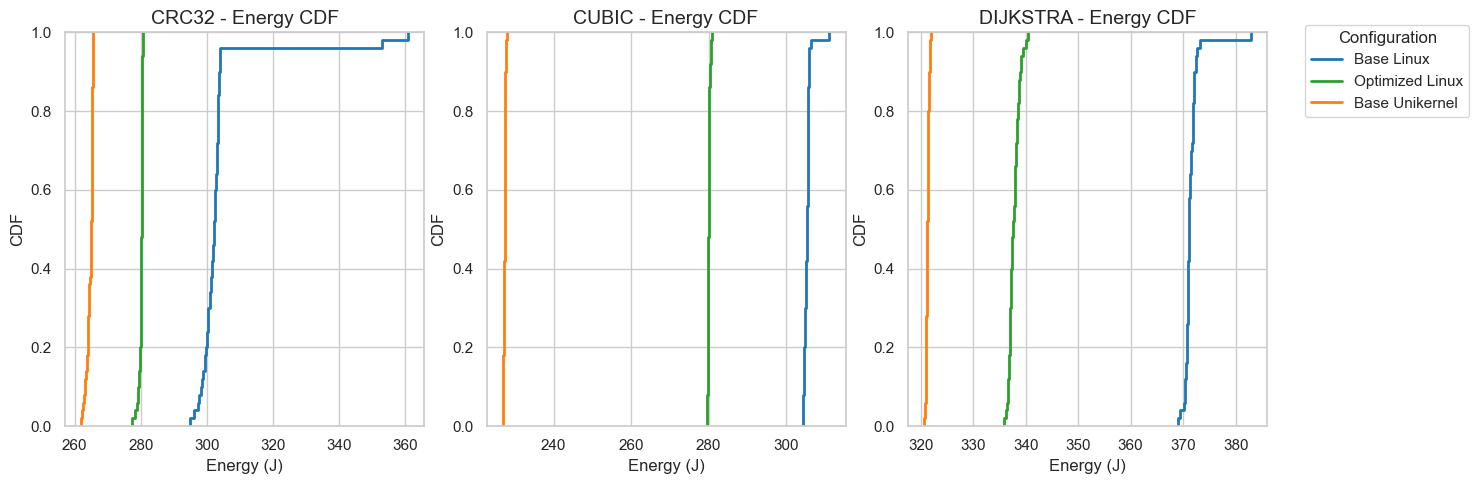

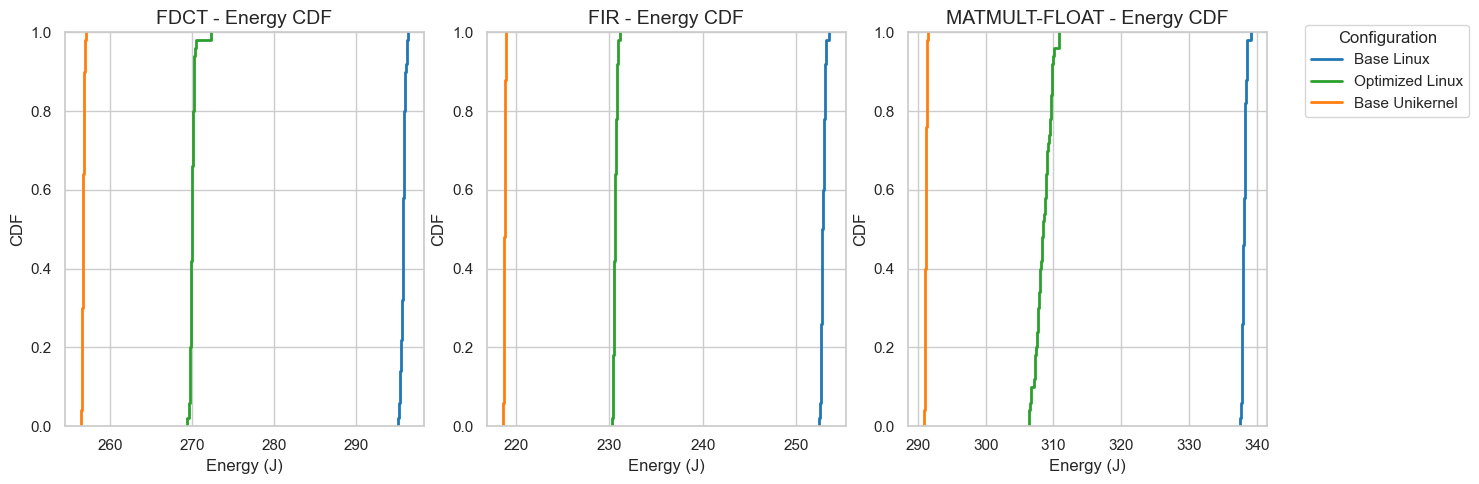

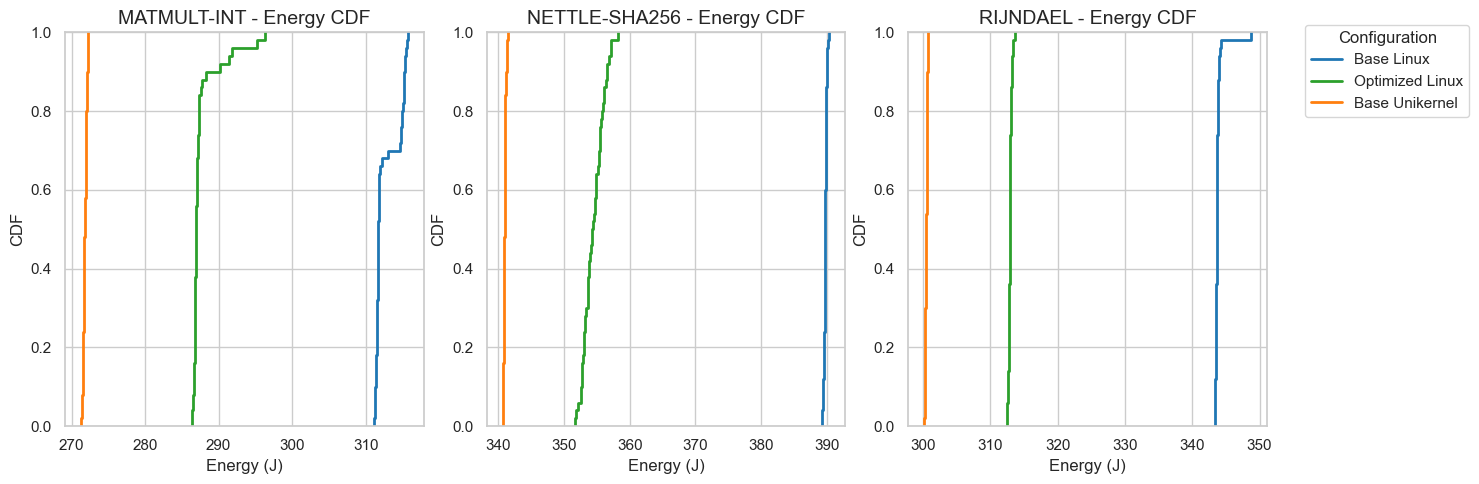

In [ ]:
# Get all benchmarks and split into groups of 3
all_benchmarks = all_data['benchmark'].unique().tolist()
benchmark_groups = [all_benchmarks[i:i+3] for i in range(0, len(all_benchmarks), 3)]

# Define consistent color palette
palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']  # Base Linux, Optimized Linux, Base Unikernel, Optimized Unikernel
hue_order = ['Base Linux', 'Optimized Linux', 'Base Unikernel', 'Optimized Unikernel']

# Create CDF plots for each group of 3 benchmarks
for group_idx, benchmarks_to_plot in enumerate(benchmark_groups):
    n_plots = len(benchmarks_to_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    
    # Handle single plot case
    if n_plots == 1:
        axes = [axes]
    
    for idx, benchmark in enumerate(benchmarks_to_plot):
        ax = axes[idx]
        benchmark_data = all_data[all_data['benchmark'] == benchmark]
        
        # Use seaborn's ecdfplot for CDF
        sns.ecdfplot(
            data=benchmark_data, 
            x='total_joules', 
            hue='source',
            hue_order=hue_order,
            palette=palette,
            linewidth=2,
            ax=ax
        )
        
        ax.set_xlabel('Energy (J)', fontsize=12)
        ax.set_ylabel('CDF', fontsize=12)
        ax.set_title(f'{benchmark.upper()} - Energy CDF', fontsize=14)
        
        # Get legend and remove it from individual plots
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    # Create custom legend with proper labels
    from matplotlib.lines import Line2D
    custom_handles = [Line2D([0], [0], color=c, linewidth=2) for c in palette]
    fig.legend(custom_handles, hue_order, title='Configuration', loc='upper right', bbox_to_anchor=(0.99, 0.95))

    plt.tight_layout()
    plt.subplots_adjust(right=0.82)  # Make room for legend
    # plt.savefig(f'energy_cdf_group{group_idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

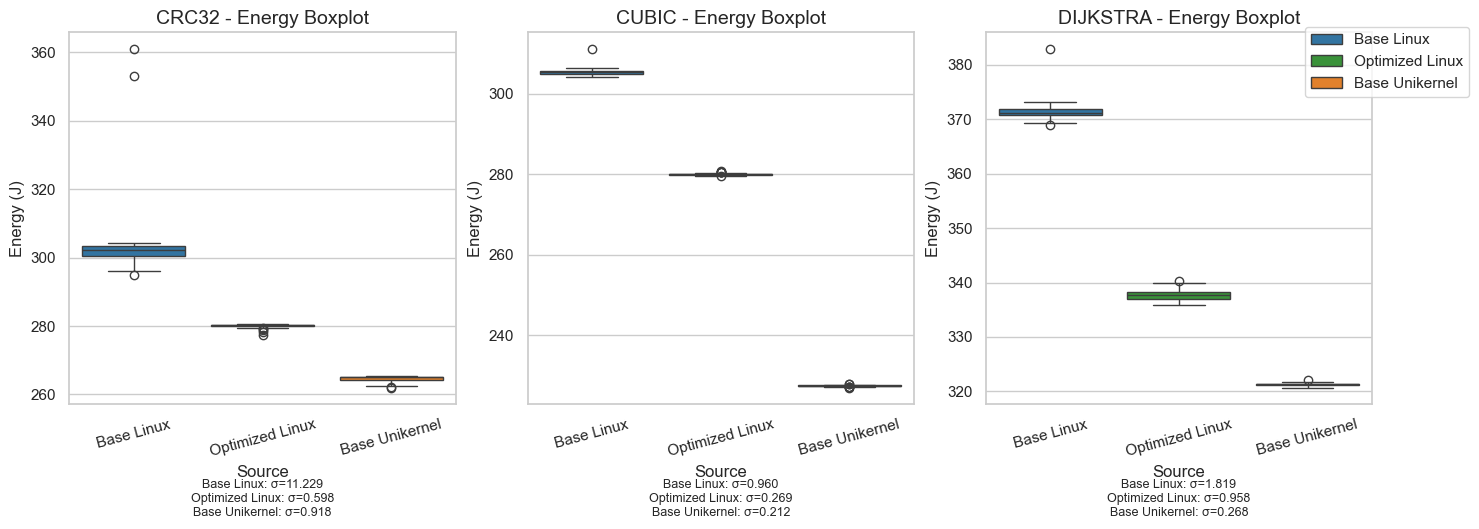

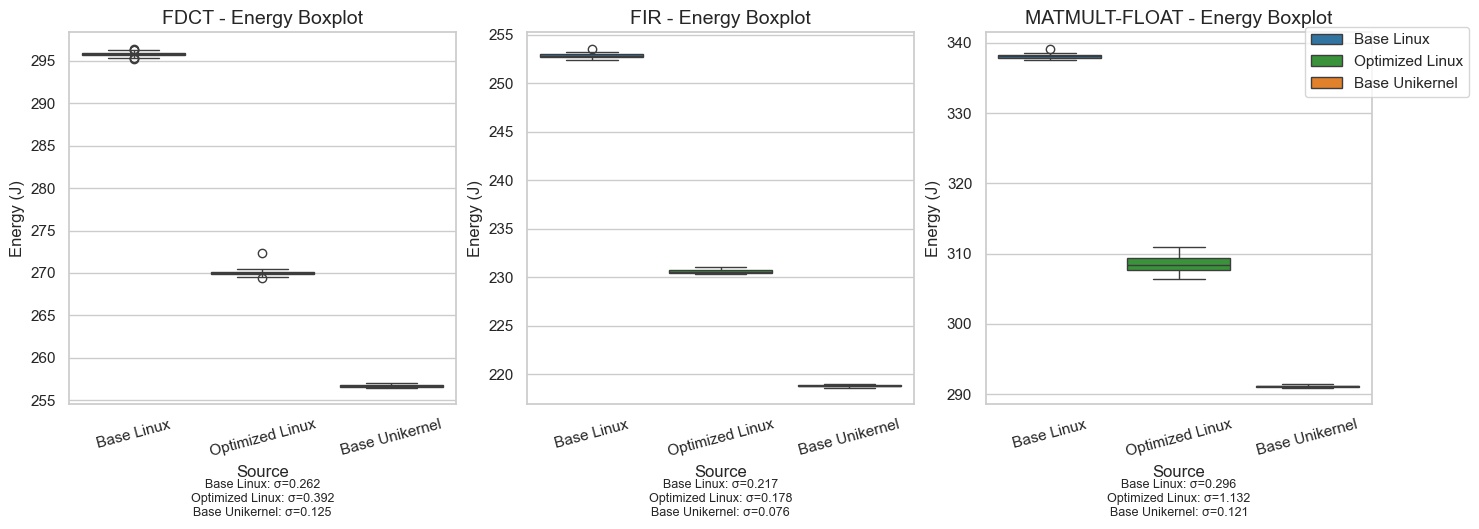

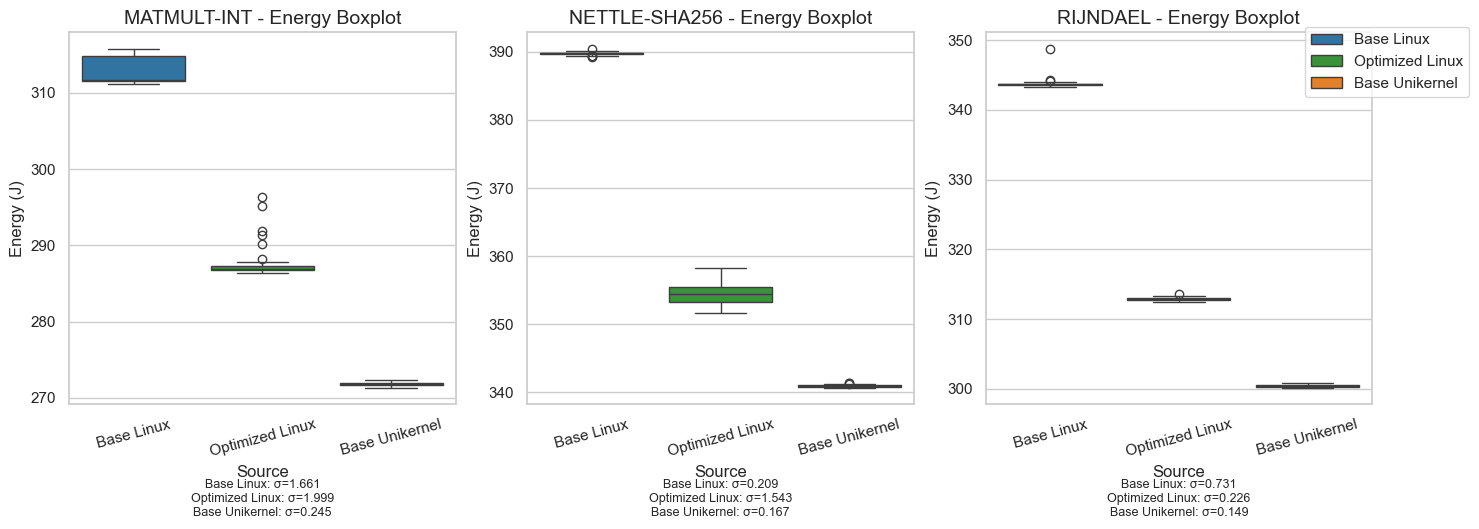

In [ ]:
# Create boxplots for each group of 3 benchmarks
for group_idx, benchmarks_to_plot in enumerate(benchmark_groups):
    n_plots = len(benchmarks_to_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5.5))
    
    # Handle single plot case
    if n_plots == 1:
        axes = [axes]

    for idx, benchmark in enumerate(benchmarks_to_plot):
        ax = axes[idx]
        benchmark_data = all_data[all_data['benchmark'] == benchmark]
        
        sns.boxplot(
            data=benchmark_data,
            x='source',
            y='total_joules',
            hue='source',
            hue_order=hue_order,
            palette=palette,
            ax=ax,
            order=hue_order,
            legend=(idx == 0)  # Only show legend on first plot
        )
        
        ax.set_xlabel('Source', fontsize=12)
        ax.set_ylabel('Energy (J)', fontsize=12)
        ax.set_title(f'{benchmark.upper()} - Energy Boxplot', fontsize=14)
        ax.tick_params(axis='x', rotation=20)
        # ax.set_ylim(bottom=0)
        
        # Calculate and display std deviation for each source (in J)
        std_text = []
        for source in hue_order:
            source_data = benchmark_data[benchmark_data['source'] == source]['total_joules']
            std = source_data.std()
            std_text.append(f"{source}: σ={std:.3f}")
        
        ax.text(0.5, -0.25, '\n'.join(std_text), transform=ax.transAxes, 
                fontsize=8, ha='center', va='top')

    # Add a single legend for all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.95))
    axes[0].get_legend().remove()

    plt.tight_layout()
    plt.subplots_adjust(right=0.88, bottom=0.30)  # Make room for legend and std text
    # plt.savefig(f'energy_boxplot_group{group_idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()